   platform                               show_id      mean   median  count
1    Reddit          2016_Coldplay_Beyonce_Bruno_  0.163966  0.06390    360
5    Reddit                          2023_Rihanna  0.145917  0.00000    360
3    Reddit           2020_Shakira_Jennifer_Lopez  0.124908  0.00000    360
0    Reddit                       2015_Katy_Perry  0.122152  0.00000    360
2    Reddit                        2017_Lady_Gaga  0.106486  0.00000    360
4    Reddit           2022_Dr_Dre_Snoop_Dogg_Emin  0.100039  0.00000    360
8   YouTube                        2017_Lady_Gaga  0.310666  0.42150    954
11  YouTube                          2023_Rihanna  0.277344  0.19010    954
9   YouTube                      2020_Shakira_JLo  0.267719  0.31820    954
6   YouTube                       2015_Katy_Perry  0.262027  0.22535    954
7   YouTube           2016_Coldplay_Beyonce_Bruno  0.259766  0.27320    954
10  YouTube  2022_Dre_Snoop_Eminem_MaryJ_Kendrick  0.216024  0.00000    954
  platform  

C:\Users\miso9\AppData\Local\Temp\ipykernel_42212\3867424475.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=order, showfliers=False)


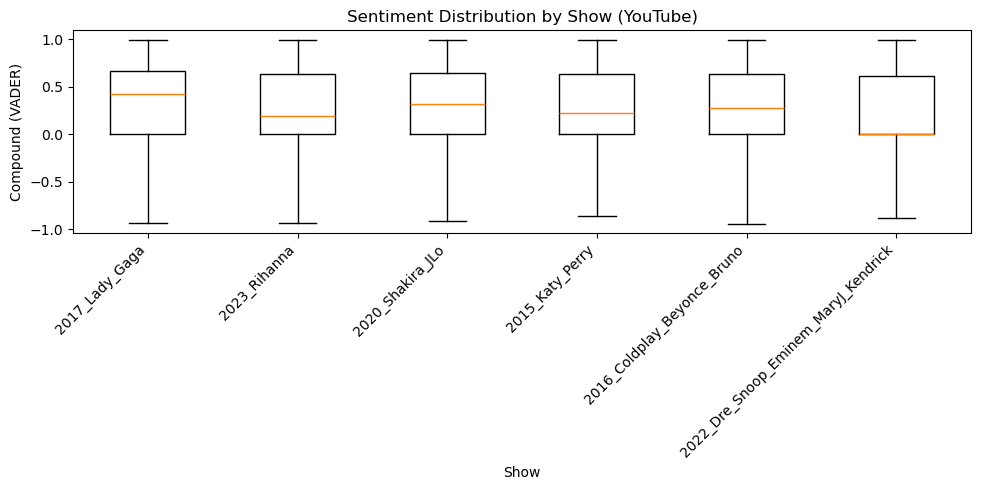

C:\Users\miso9\AppData\Local\Temp\ipykernel_42212\3867424475.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=order, showfliers=False)


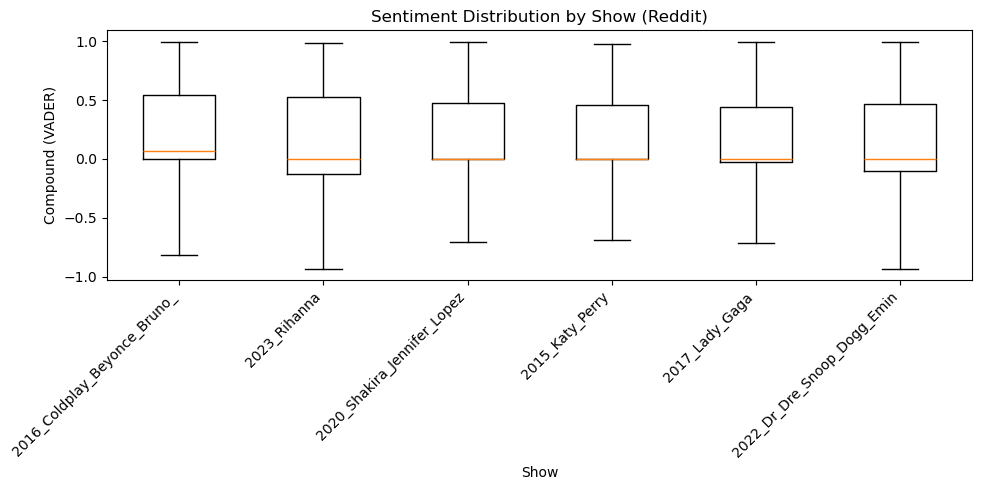

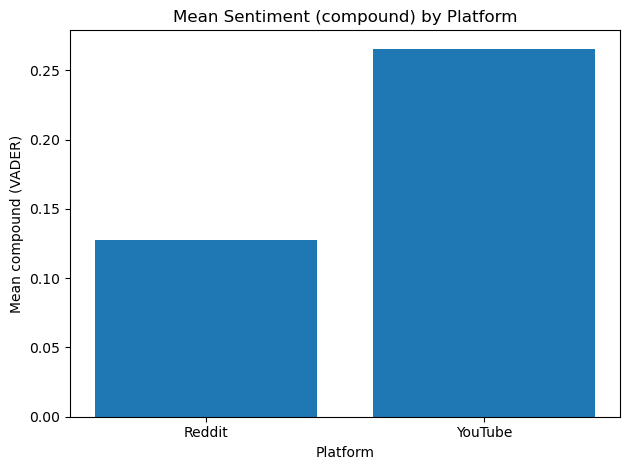

[Summary] YouTube mean=0.266, Reddit mean=0.127. Reddit’s distribution appears flatter/more polarized; illustrate this pattern in figures.


C:\Users\miso9\AppData\Local\Temp\ipykernel_42212\3867424475.py:151: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  yt_mean = float(by_plat.loc[by_plat["platform"]=="YouTube","compound"])
C:\Users\miso9\AppData\Local\Temp\ipykernel_42212\3867424475.py:152: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rd_mean = float(by_plat.loc[by_plat["platform"]=="Reddit","compound"])


In [2]:
# ============================================
# Day 3: VADER Sentiment + Quick EDA (One-Cell)
# - Input: Reddit/YouTube CSVs (balanced recommended)
# - Output: compound & pos/neu/neg + 2 plots
# ============================================

import os, re, unicodedata
import numpy as np
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import matplotlib.pyplot as plt

# -----------------------------
# 0) File paths (EDIT HERE)
# -----------------------------
# Adjust paths for your local/Colab environment.
PATH_YT = r"comments_yt_180d_clean_balanced.csv"       # e.g., r"C:\Users\...\comments_yt_180d_clean_balanced.csv"
PATH_RD = r"comments_reddit_180d_clean_balanced.csv"   # e.g., r"C:\Users\...\comments_reddit_180d_clean_balanced.csv"

# -----------------------------
# 1) Load
# -----------------------------
yt = pd.read_csv(PATH_YT)
rd = pd.read_csv(PATH_RD)

# -----------------------------
# 2) Normalize show id (absorb naming differences)
#   - Beyoncé → Beyonce, remove punctuation, spaces → underscores
# -----------------------------
def normalize_show_key(x: str) -> str:
    if pd.isna(x): return x
    x = str(x)
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('ascii')  # remove accents
    x = re.sub(r'[^A-Za-z0-9 _]', ' ', x)  # remove punctuation
    x = re.sub(r'\s+', ' ', x).strip()
    x = x.replace(' ', '_')
    x = re.sub(r'_+', '_', x)
    return x

def add_show_id_norm(df):
    df = df.copy()
    # try common column names
    cand = None
    for c in ["show_id","show_key","show","show name"]:
        if c in df.columns: 
            cand = c; break
    if cand is None:
        cands = [c for c in df.columns if "show" in c.lower()]
        cand = cands[0] if cands else None
    if cand is None:
        raise KeyError("Could not find a show identifier column (e.g., show_id/show_key).")
    df["show_id_norm"] = df[cand].astype(str).apply(normalize_show_key)
    return df

yt = add_show_id_norm(yt)
rd = add_show_id_norm(rd)

# -----------------------------
# 3) Standardize timestamp (optional) & select minimal columns
# -----------------------------
def extract_ts(df):
    cols = [c for c in df.columns if any(k in c.lower() for k in ["published","created","time","date","timestamp","ts"])]
    ts_col = cols[0] if cols else None
    ts = pd.to_datetime(df[ts_col], errors="coerce") if ts_col else pd.NaT
    return ts

def pick_cols(df, platform_name):
    out = pd.DataFrame({
        "show_id": df["show_id_norm"],
        "platform": platform_name,
        "text": df["text"] if "text" in df.columns else df.iloc[:,0].astype(str),  # fallback if text column name differs
        "ts": extract_ts(df)
    })
    # append phase if available
    if "phase" in df.columns:
        out["phase"] = df["phase"]
    return out

yt_s = pick_cols(yt, "YouTube")
rd_s = pick_cols(rd, "Reddit")
data = pd.concat([yt_s, rd_s], ignore_index=True)
data = data.dropna(subset=["text","show_id"])

# -----------------------------
# 4) VADER sentiment
# -----------------------------
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()
sc = data["text"].astype(str).apply(sia.polarity_scores).apply(pd.Series)
data = pd.concat([data, sc], axis=1)

def to_label(compound):
    if compound >= 0.05: return "pos"
    if compound <= -0.05: return "neg"
    return "neu"

data["sentiment"] = data["compound"].apply(to_label)

# -----------------------------
# 5) Quick tables (for sanity check)
# -----------------------------
# Platform × show: mean/median/count
by_show_plat = (data.groupby(["platform","show_id"])["compound"]
                .agg(mean="mean", median="median", count="count")
                .reset_index()
                .sort_values(["platform","mean"], ascending=[True, False]))
print(by_show_plat.head(12))

# Platform-level means (pre/post split will be done in Day 5)
by_plat = data.groupby("platform")["compound"].mean().reset_index()
print(by_plat)

# -----------------------------
# 6) Plots (2 required)
#   (A) Boxplot/Violin: show × platform
#   (B) Mean bar: platform
#   Note: use matplotlib only (per assignment)
# -----------------------------

# (A) Boxplots per platform across shows
for plat in data["platform"].unique():
    sub = data[data["platform"]==plat]
    # order shows by mean compound (descending)
    order = (sub.groupby("show_id")["compound"]
             .mean().sort_values(ascending=False).index.tolist())
    # boxplot
    plt.figure(figsize=(10,5))
    # build values per show in the chosen order
    vals = [sub.loc[sub["show_id"]==sid, "compound"].values for sid in order]
    plt.boxplot(vals, labels=order, showfliers=False)
    plt.title(f"Sentiment Distribution by Show ({plat})")
    plt.xlabel("Show")
    plt.ylabel("Compound (VADER)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# (B) Mean sentiment by platform
plt.figure()
plt.bar(by_plat["platform"], by_plat["compound"])
plt.title("Mean Sentiment (compound) by Platform")
plt.xlabel("Platform")
plt.ylabel("Mean compound (VADER)")
plt.tight_layout()
plt.show()

# -----------------------------
# 7) One-line takeaway (summary)
# -----------------------------
yt_mean = float(by_plat.loc[by_plat["platform"]=="YouTube","compound"])
rd_mean = float(by_plat.loc[by_plat["platform"]=="Reddit","compound"])
pol_msg = "Reddit’s distribution appears flatter/more polarized; illustrate this pattern in figures."
print(f"[Summary] YouTube mean={yt_mean:.3f}, Reddit mean={rd_mean:.3f}. {pol_msg}")


In [3]:
import re

def canon_show_id(s: str) -> str:
    if not isinstance(s, str): return s
    s = s.strip("_")
    s = s.replace("Jennifer_Lopez", "JLo")
    s = s.replace("Dr_Dre", "Dre")
    s = s.replace("Snoop_Dogg", "Snoop")
    # If the key starts with 2022_, coerce to the canonical full name
    if s.startswith("2022_"):
        s = "2022_Dre_Snoop_Eminem_MaryJ_Kendrick"
    return s

# ⬇️ Apply this right before building the pivot
data["show_id"] = data["show_id"].astype(str).apply(canon_show_id)

platform_means = data.pivot_table(index="show_id", columns="platform",
                                  values="compound", aggfunc="mean")
platform_means["YouTube_minus_Reddit"] = platform_means["YouTube"] - platform_means["Reddit"]
platform_means = platform_means.sort_values("YouTube_minus_Reddit", ascending=False)
print(platform_means)

# (Optional) Alternative using .get() to avoid KeyError if a platform column is missing
platform_means = data.pivot_table(index="show_id", columns="platform", values="compound", aggfunc="mean")
platform_means["YouTube_minus_Reddit"] = platform_means.get("YouTube", 0) - platform_means.get("Reddit", 0)
platform_means.sort_values("YouTube_minus_Reddit", ascending=False)


platform                                Reddit   YouTube  YouTube_minus_Reddit
show_id                                                                       
2017_Lady_Gaga                        0.106486  0.310666              0.204180
2020_Shakira_JLo                      0.124908  0.267719              0.142812
2015_Katy_Perry                       0.122152  0.262027              0.139874
2023_Rihanna                          0.145917  0.277344              0.131427
2022_Dre_Snoop_Eminem_MaryJ_Kendrick  0.100039  0.216024              0.115984
2016_Coldplay_Beyonce_Bruno           0.163966  0.259766              0.095800


platform,Reddit,YouTube,YouTube_minus_Reddit
show_id,,,
2017_Lady_Gaga,0.106486,0.310666,0.204180
2020_Shakira_JLo,0.124908,0.267719,0.142812
2015_Katy_Perry,0.122152,0.262027,0.139874
2023_Rihanna,0.145917,0.277344,0.131427
2022_Dre_Snoop_Eminem_MaryJ_Kendrick,0.100039,0.216024,0.115984
2016_Coldplay_Beyonce_Bruno,0.163966,0.259766,0.095800


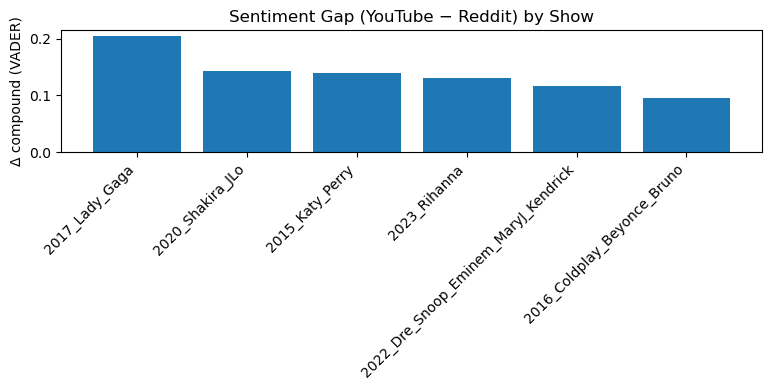

In [9]:
import matplotlib.pyplot as plt

tmp = platform_means["YouTube_minus_Reddit"].sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.bar(tmp.index, tmp.values)
plt.title("Sentiment Gap (YouTube − Reddit) by Show")
plt.ylabel("Δ compound (VADER)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Axes: xlabel='platform,platform'>

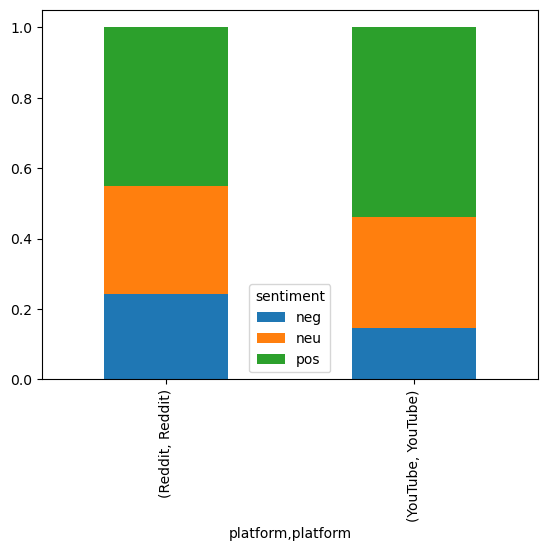

In [7]:
dist = (data.groupby(["platform","sentiment"]).size()
        .groupby(level=0).apply(lambda s: s/s.sum()).unstack(fill_value=0))
dist.plot(kind="bar", stacked=True)  

**Using VADER on the balanced dataset, YouTube comments are consistently more positive than Reddit (mean compound 0.266 vs 0.127). Because sampling is equalized across shows, this difference reflects a platform effect rather than show mix. Boxplots further indicate flatter, more polarized distributions on Reddit (medians ≈ 0 across shows).**


[Unbalanced] Platform × show (raw means):
    platform                               show_id      mean   median  count
1    Reddit           2016_Coldplay_Beyonce_Bruno  0.177650  0.07720   2136
5    Reddit                          2023_Rihanna  0.157358  0.02580   6387
3    Reddit                      2020_Shakira_JLo  0.146683  0.00000   3575
4    Reddit  2022_Dre_Snoop_Eminem_MaryJ_Kendrick  0.146068  0.00000   9165
2    Reddit                        2017_Lady_Gaga  0.141327  0.00000   3961
0    Reddit                       2015_Katy_Perry  0.122152  0.00000    360
8   YouTube                        2017_Lady_Gaga  0.305910  0.38500   3681
11  YouTube                          2023_Rihanna  0.275580  0.22350   2346
7   YouTube           2016_Coldplay_Beyonce_Bruno  0.263744  0.30080   2483
6   YouTube                       2015_Katy_Perry  0.262027  0.22535    954
9   YouTube                      2020_Shakira_JLo  0.249675  0.22630   2791
10  YouTube  2022_Dre_Snoop_Eminem_MaryJ_Ken

C:\Users\miso9\AppData\Local\Temp\ipykernel_42212\3233728202.py:140: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(wavg)
C:\Users\miso9\AppData\Local\Temp\ipykernel_42212\3233728202.py:145: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(wavg)
C:\Users\miso9\AppData\Local\Temp\ipykernel_42212\3233728202.py:164: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 't

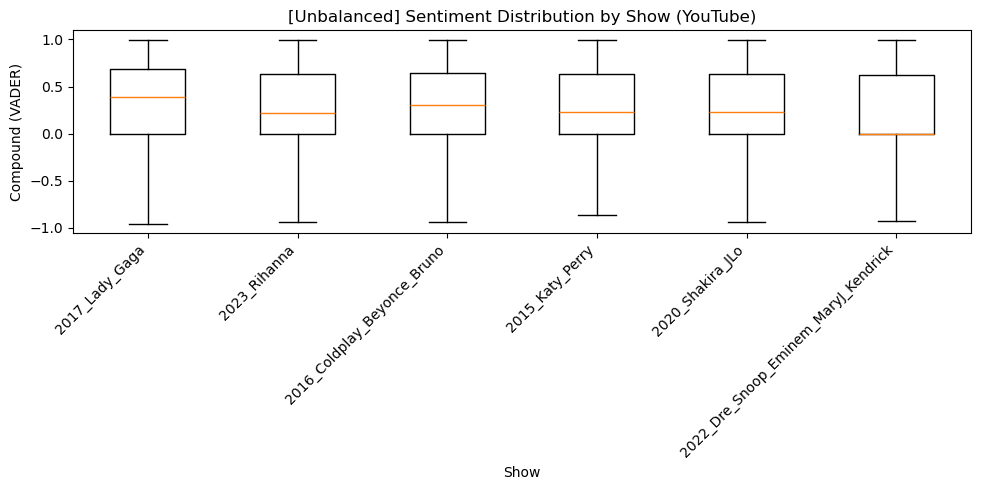

C:\Users\miso9\AppData\Local\Temp\ipykernel_42212\3233728202.py:164: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=order, showfliers=False)


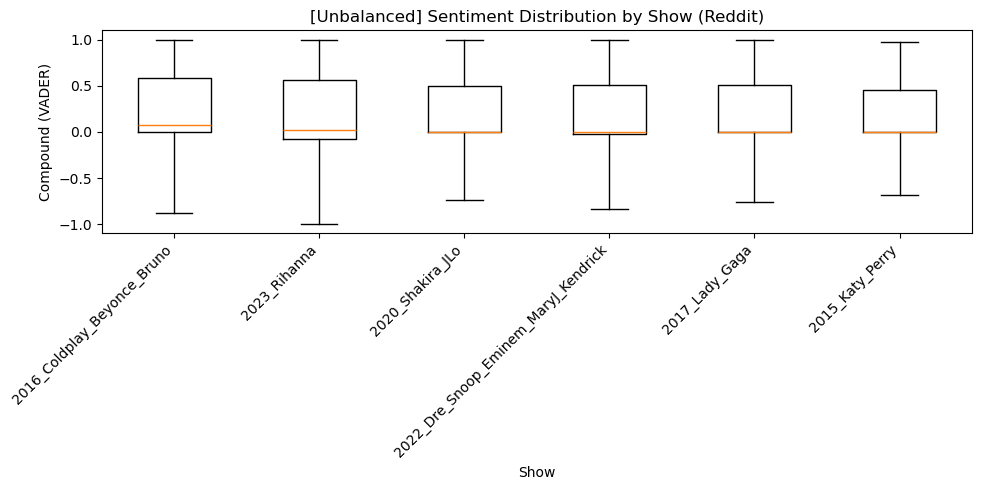

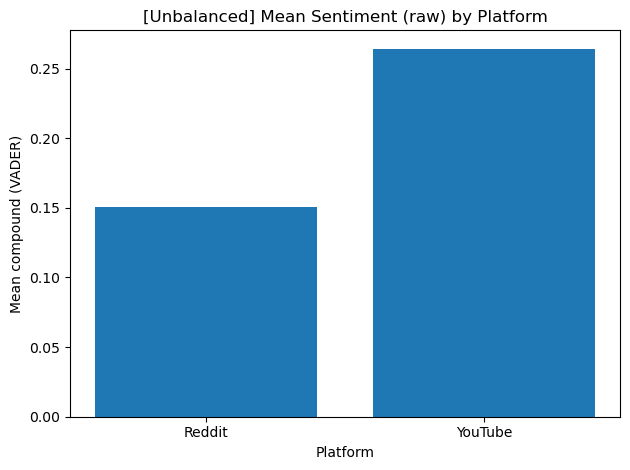

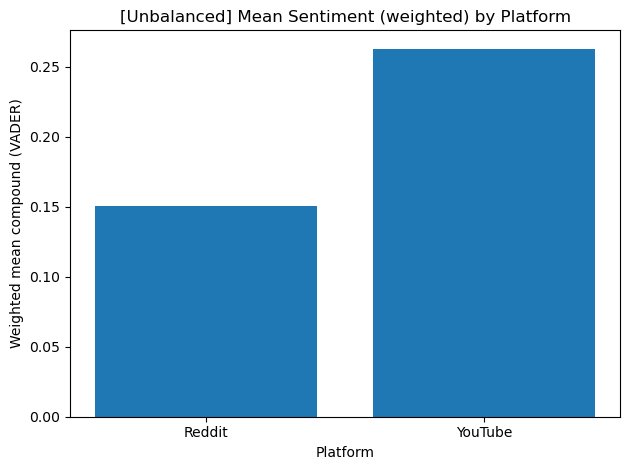

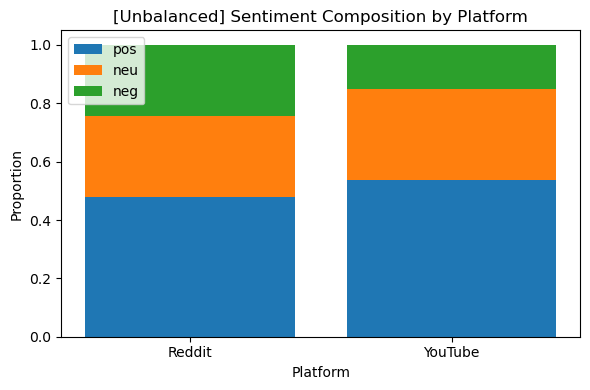


[Compare] Platform means:
   platform  compound_balanced  compound_unbalanced_raw  _unbalanced_weighted
0   Reddit           0.127245                 0.150539              0.150539
1  YouTube           0.265591                 0.264260              0.262856


In [4]:
# ======================================================
# Day 3 (Unbalanced Extension): VADER + Quick EDA
# - Input: Reddit/YouTube UNBALANCED CSVs
# - Output: same metrics/plots as balanced + (optional) weighted means
# ======================================================

import os, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# -----------------------------
# 0) File paths (EDIT HERE)
# -----------------------------
PATH_YT_U = r"comments_yt_180d_clean_unbalanced.csv"
PATH_RD_U = r"comments_reddit_180d_clean_unbalanced.csv"
PATH_SHOWS = r"shows.csv"  # optional for later Day 5; not strictly needed for Day 3

# -----------------------------
# 1) Reuse helpers from the balanced section
#    (If not defined above, uncomment and reuse here)
# -----------------------------
def normalize_show_key(x: str) -> str:
    if pd.isna(x): return x
    x = str(x)
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('ascii')
    x = re.sub(r'[^A-Za-z0-9 _]', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    x = x.replace(' ', '_')
    x = re.sub(r'_+', '_', x)
    return x

def add_show_id_norm(df):
    df = df.copy()
    cand = None
    for c in ["show_id","show_key","show","show name"]:
        if c in df.columns:
            cand = c; break
    if cand is None:
        cands = [c for c in df.columns if "show" in c.lower()]
        cand = cands[0] if cands else None
    if cand is None:
        raise KeyError("Could not find a show identifier column (e.g., show_id/show_key).")
    df["show_id_norm"] = df[cand].astype(str).apply(normalize_show_key)
    return df

def extract_ts(df):
    cols = [c for c in df.columns if any(k in c.lower() for k in ["published","created","time","date","timestamp","ts"])]
    ts_col = cols[0] if cols else None
    ts = pd.to_datetime(df[ts_col], errors="coerce") if ts_col else pd.NaT
    return ts

def pick_cols(df, platform_name):
    out = pd.DataFrame({
        "show_id": df["show_id_norm"],
        "platform": platform_name,
        "text": df["text"] if "text" in df.columns else df.iloc[:,0].astype(str),
        "ts": extract_ts(df)
    })
    # pass-through common weight column (if present)
    for wcol in ["w_show_equal", "weight", "weights"]:
        if wcol in df.columns:
            out[wcol] = df[wcol]
            break
    # optional phase
    if "phase" in df.columns:
        out["phase"] = df["phase"]
    return out

def to_label(compound):
    if compound >= 0.05: return "pos"
    if compound <= -0.05: return "neg"
    return "neu"

def canon_show_id(s: str) -> str:
    if not isinstance(s, str): return s
    s = s.strip("_")
    s = s.replace("Jennifer_Lopez", "JLo")
    s = s.replace("Dr_Dre", "Dre")
    s = s.replace("Snoop_Dogg", "Snoop")
    if s.startswith("2022_"):
        s = "2022_Dre_Snoop_Eminem_MaryJ_Kendrick"
    return s

# -----------------------------
# 2) Load unbalanced data
# -----------------------------
ytu = pd.read_csv(PATH_YT_U)
rdu = pd.read_csv(PATH_RD_U)
ytu = add_show_id_norm(ytu)
rdu = add_show_id_norm(rdu)

ytu_s = pick_cols(ytu, "YouTube")
rdu_s = pick_cols(rdu, "Reddit")
data_u = pd.concat([ytu_s, rdu_s], ignore_index=True)
data_u = data_u.dropna(subset=["text","show_id"])

# (Make a canonical show_id to align names across platforms)
data_u["show_id"] = data_u["show_id"].astype(str).apply(canon_show_id)

# -----------------------------
# 3) VADER on unbalanced
# -----------------------------
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()
sc_u = data_u["text"].astype(str).apply(sia.polarity_scores).apply(pd.Series)
data_u = pd.concat([data_u, sc_u], axis=1)
data_u["sentiment"] = data_u["compound"].apply(to_label)

# -----------------------------
# 4) Unbalanced (raw) summaries
# -----------------------------
by_show_plat_u = (data_u.groupby(["platform","show_id"])["compound"]
                  .agg(mean="mean", median="median", count="count")
                  .reset_index()
                  .sort_values(["platform","mean"], ascending=[True, False]))
print("\n[Unbalanced] Platform × show (raw means):\n", by_show_plat_u.head(12))

by_plat_u = data_u.groupby("platform")["compound"].mean().reset_index()
print("\n[Unbalanced] Platform means (raw):\n", by_plat_u)

# -----------------------------
# 5) Weighted summaries (optional but recommended)
#    - Use 'w_show_equal' if present; otherwise default to 1.0
#    - This dampens show imbalance in the unbalanced set
# -----------------------------
wcol = "w_show_equal" if "w_show_equal" in data_u.columns else None
if wcol is None:
    data_u["_w"] = 1.0
    wcol = "_w"
else:
    data_u["_w"] = data_u[wcol].astype(float).fillna(1.0)

def wavg(group):
    return np.average(group["compound"], weights=group["_w"])

w_by_plat = (data_u.groupby("platform")
             .apply(wavg)
             .reset_index(name="w_mean_compound"))
print("\n[Unbalanced] Platform means (weighted):\n", w_by_plat)

w_by_show_plat = (data_u.groupby(["platform","show_id"])
                  .apply(wavg)
                  .reset_index(name="w_mean_compound")
                  .sort_values(["platform","w_mean_compound"], ascending=[True, False]))
print("\n[Unbalanced] Platform × show (weighted means):\n", w_by_show_plat.head(12))

# -----------------------------
# 6) Plots (unbalanced, raw)
#    (A) Boxplots per platform across shows
#    (B) Mean bar by platform (raw)
#    (C) (Optional) Weighted mean bar by platform
# -----------------------------

# (A) Boxplots (raw)
for plat in data_u["platform"].unique():
    sub = data_u[data_u["platform"]==plat]
    order = (sub.groupby("show_id")["compound"]
             .mean().sort_values(ascending=False).index.tolist())
    vals = [sub.loc[sub["show_id"]==sid, "compound"].values for sid in order]
    plt.figure(figsize=(10,5))
    plt.boxplot(vals, labels=order, showfliers=False)
    plt.title(f"[Unbalanced] Sentiment Distribution by Show ({plat})")
    plt.xlabel("Show")
    plt.ylabel("Compound (VADER)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# (B) Mean bar (raw)
plt.figure()
plt.bar(by_plat_u["platform"], by_plat_u["compound"])
plt.title("[Unbalanced] Mean Sentiment (raw) by Platform")
plt.xlabel("Platform")
plt.ylabel("Mean compound (VADER)")
plt.tight_layout()
plt.show()

# (C) Weighted mean bar (optional)
plt.figure()
plt.bar(w_by_plat["platform"], w_by_plat["w_mean_compound"])
plt.title("[Unbalanced] Mean Sentiment (weighted) by Platform")
plt.xlabel("Platform")
plt.ylabel("Weighted mean compound (VADER)")
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Stacked sentiment proportions by platform (matplotlib)
#    (pos/neu/neg shares)
# -----------------------------
sent_counts = (data_u.groupby(["platform","sentiment"])
               .size()
               .unstack(fill_value=0))
# normalize rows to get proportions
sent_props = sent_counts.div(sent_counts.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
platforms = list(sent_props.index)
pos_vals = sent_props.get("pos", pd.Series(0, index=platforms))
neu_vals = sent_props.get("neu", pd.Series(0, index=platforms))
neg_vals = sent_props.get("neg", pd.Series(0, index=platforms))

# stacked bars
plt.bar(platforms, pos_vals, label="pos")
plt.bar(platforms, neu_vals, bottom=pos_vals, label="neu")
plt.bar(platforms, neg_vals, bottom=pos_vals+neu_vals, label="neg")
plt.title("[Unbalanced] Sentiment Composition by Platform")
plt.xlabel("Platform")
plt.ylabel("Proportion")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 8) (Optional) Quick side-by-side comparison vs. balanced
#     - If 'by_plat' from balanced section exists in memory
# -----------------------------
try:
    comp = by_plat.merge(by_plat_u, on="platform", suffixes=("_balanced","_unbalanced_raw"))
    comp = comp.merge(w_by_plat, on="platform", how="left")
    comp = comp.rename(columns={"w_mean_compound":"_unbalanced_weighted"})
    print("\n[Compare] Platform means:\n", comp)
except Exception as e:
    print("\n[Compare] Skipped side-by-side summary (balanced variables not found in this session).")


**Using VADER on the unbalanced dataset, YouTube remains consistently more positive than Reddit (mean compound 0.264 vs 0.151). Applying show-level weights (w_show_equal) yields virtually identical platform means (0.263 vs 0.151), indicating that the conclusion is robust to the underlying engagement imbalance. Reddit’s distributions are flatter and more polarized (medians ≈ 0 across shows).**